In [24]:
import os
import random
import time
import gc

import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from datetime import date

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)


DATAPATH = 'external/amn_release/Dataset_model/e_coli_core_UB_15400.npz' 

In [25]:
def set_seed(seed=42):
    """
    Set all random seeds for reproducibility across different devices.
    
    Args:
        seed (int): Random seed value (default: 42)
    """
    # Python random module
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch CPU
    torch.manual_seed(seed)
    
    # PyTorch CUDA (NVIDIA GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # PyTorch MPS (Apple Silicon)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    
    
    os.environ['PYTHONHASHSEED'] = str(seed)

In [26]:

def get_device(device_type=None):
    """
    Select device with manual override option
    
    Args:
        device_type: 'cuda', 'mps', 'cpu', or None for auto-selection
    """
    if device_type:
        return torch.device(device_type)
    
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

Training on device: mps
PyTorch version: 2.7.1


In [27]:
def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active device (CUDA or MPS).
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'CUDA Allocated memory: {allocated:.2f} MB')
        print(f'CUDA Reserved memory: {reserved:.2f} MB')
    elif torch.backends.mps.is_available():
        allocated = torch.mps.current_allocated_memory() / 1024**2
        reserved = torch.mps.driver_allocated_memory() / 1024**2
        print(f'MPS Allocated memory: {allocated:.2f} MB')
        print(f'MPS Driver allocated memory: {reserved:.2f} MB')
    else:
        print("Neither CUDA nor MPS is available.")

In [28]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [29]:
# pre-norm

class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [30]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c

In [31]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=2742,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.2,
        input_length=30
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.input_length = input_length

        self.input_embedding = nn.Embedding(vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        Args:
            c: (batch, 1) or (batch, seq, 1) context tensor
            output_subset: 1D tensor of indices (subset of outputs) or None
            return_embedding: if True, return embeddings instead of c

        Returns:
            c: updated context
            selected_indices: indices of tokens used (always include inputs 0..29)
        """
        batch_size = c.size(0)

        # Always include input indices
        input_indices = torch.arange(self.input_length, device=c.device)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            # Concatenate inputs + sampled outputs
            selected_indices = torch.cat([input_indices, output_subset.to(c.device)])
            selected_indices = torch.unique(selected_indices, sorted=True)

        # Expand indices for batch
        y = selected_indices.unsqueeze(0).expand(batch_size, -1)  # (B, seq_subset)
        x = self.input_embedding(y)  # (B, seq_subset, d_model)

        # Slice c to selected indices
        c_subset = c[:, selected_indices, :]

        c_subset_all_layers = torch.zeros(batch_size, c_subset.size()[1], len(self.layers), device=c.device)

        for e,layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices  # embeddings + indices

        return c_subset_all_layers, selected_indices

In [32]:
def load_data(filepath=DATAPATH):
    """
    Load and preprocess metabolic flux training data
    
    Parameters:
        filepath (str): Path to the .npz file.

    Returns:
        X_combined (ndarray): Combined input matrix (inputs in the first columns, outputs are zeros).
        y_combined (ndarray): Combined output matrix (inputs are zeros, outputs in the last columns).
        all_columns (list): List of column names (input + output).
    """
    
    data = np.load(filepath)

    X = data['X']
    y = data['Y']

    # Normalize the output targets
    #scaler = StandardScaler()
    #y_normalized = scaler.fit_transform(y)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, [str(s) for s in data['medium']],  [str(s) for s in data['measure']] 

In [33]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [34]:
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    """
    Create PyTorch DataLoaders for training and testing.

    Parameters:
        X_train, y_train (Tensor): Training data and labels.
        X_test, y_test (Tensor): Test data and labels.
        batch_size (int): Batch size for loading.

    Returns:
        train_loader, test_loader (DataLoader): PyTorch DataLoaders.
    """
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [35]:
# Load and preprocess data

X, y, input_cols, output_cols = load_data(DATAPATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)

Training samples: 9240
Test samples: 6160


In [36]:
data = np.load(DATAPATH)
S = data['S']

In [14]:
def train_model(
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=640,
    num_epochs=100,
    learning_rate=0.001,
    dropout=0.02,
    output_sample_ratio=0.5
):
    start_time = time.time()

    model = FluxTransformer(
        vocab_size=len(input_cols)+len(output_cols),
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout
    ).to(device)
    
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=1e-4
    )
    criterion = nn.HuberLoss()

    best_test_loss = float('inf')
    best_epoch = -1

    train_losses = []
    test_losses = []

    total_outputs = len(output_cols)
    output_start_idx = len(input_cols)

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Randomly sample subset of outputs
            if output_sample_ratio >= 1.0:
                sampled_indices = None  # pass None to FluxTransformer.forward()
            else:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                    random.sample(range(output_start_idx, output_start_idx + total_outputs), n_sampled),
                    device=device
                )

            #print(batch_X.size(),batch_y.size())
            
            predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
            
            target = batch_y[:, selected_indices, :]
            
            # print(predictions.size(),target.size())
            # print(predictions[:,:,-1].unsqueeze(2).size(),target.size())

            loss = criterion(predictions[:,:,-1].unsqueeze(2), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            elif device.type == 'mps':
                torch.mps.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                    random.sample(range(output_start_idx, output_start_idx + total_outputs), n_sampled),
                    device=device
                )

                predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
                target = batch_y[:, selected_indices, :]
                loss = criterion(predictions[:,:,-1].unsqueeze(2), target)

                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
                elif device.type == 'mps':
                    torch.mps.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            best_epoch = epoch + 1
        
        # Additional memory cleanup after epoch
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        elif device.type == 'mps':
            torch.mps.empty_cache()
        gc.collect()

    print('Training Completed.')
    end_time = time.time()
    elapsed_time = end_time - start_time
    mins, secs = divmod(elapsed_time, 60)
    print(f"Training took {int(mins)} min {secs:.1f} sec.")
    print(f"Best test loss: {best_test_loss:.6f} at epoch {best_epoch}")
    
    return train_losses, test_losses, model, optimizer

In [15]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [16]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [17]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    with torch.no_grad():
        pred, _ = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,-1].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 154 columns)
    y_pred_outputs = y_pred_full[:, 20:,-1]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"{flux_name} index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

In [19]:
def plot_output_ratio_metric(ratios, r2_values, flux_name, metric_name='r2', save_path=None):
    """
    Plot R² performance vs. output subset ratio.
    """
    plt.figure(figsize=(14, 10))
    plt.plot(ratios, r2_values, marker='o', linewidth=2)
    plt.xlabel('Output Subset Ratio', fontsize=18)
    plt.ylabel(metric_name.upper(), fontsize=18)
    plt.title(f'Impact of Output Subset Ratio on {flux_name} Prediction', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(0, 1)
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved output ratio plot to {save_path}")
        plt.close()
    else:
        plt.show()

In [20]:
def evaluate_metrics(model, X_test, y_test, output_cols, device='cpu', batch_size=16):
    """
    Evaluate a trained FluxTransformer model on test data.

    Args:
        model (nn.Module): Trained PyTorch model.
        X_test (Tensor): Test inputs, shape [n_samples, input+output features].
        y_test (Tensor): Test outputs, shape [n_samples, input+output features].
        output_cols (list of str): Names of output flux columns.
        device (str or torch.device): Device to run evaluation on.

    Returns:
        pd.DataFrame: DataFrame with columns ['flux', 'r2', 'mae'].
    """
    model = model.to(device)
    model.eval()

    y_preds = []
    y_trues = []
    
    n_samples = X_test.size(0)
    
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            x_batch = X_test[start:end].unsqueeze(-1).to(device)
            y_batch = y_test[start:end].to(device)
            
            y_pred_tensor, _ = model(x_batch)
            y_preds.append(y_pred_tensor.squeeze(-1).cpu())
            y_trues.append(y_batch.cpu())
    
    y_pred = torch.cat(y_preds, dim=0).numpy()[:, 20:]  # skip input indices
    y_true = torch.cat(y_trues, dim=0).numpy()[:, 20:]

    metrics = []
    for i, label in enumerate(output_cols):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        metrics.append({'flux': label.replace('_flux',''), 'r2': r2, 'mae': mae})

    df_metrics = pd.DataFrame(metrics)
    df_metrics['r2'] = df_metrics['r2'].map('{:.3f}'.format)
    df_metrics['mae'] = df_metrics['mae'].map('{:.4f}'.format)
    
    return df_metrics

In [51]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    print(config)
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

In [21]:
def plot_constraint_and_mass_balance_diagnostics(model, X_test, y_test, input_cols, data):
    """
    Runs the model on test data and generates a 2x2 matrix of plots:
    1. Lower bound constraint violation heatmap
    2. Histogram of lower bound violations
    3. Mass balance violation heatmap
    4. Histogram of mass balance violations
    """
    import torch
    import matplotlib.pyplot as plt

    # Move model to CPU and set to eval mode
    model_cpu = model.to('cpu')
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))

    Pin = torch.tensor(data['Pin'], dtype=torch.float32)
    S = torch.tensor(data['S'], dtype=torch.float32)

    # Lower bound constraint violations
    Loss_Vin = torch.matmul(
        y_pred_tensor[:, len(input_cols):, :].permute(0, 2, 1).to('cpu'),
        Pin.T
    ) - X_test.to('cpu').unsqueeze(1)[:, :, :len(input_cols)]
    Loss_Vin_np = Loss_Vin.squeeze(1).cpu().numpy()

    # Mass balance constraint violations
    Loss_SV = torch.matmul(
        y_pred_tensor[:, len(input_cols):, :].permute(0, 2, 1).to('cpu'),
        S.T
    )
    Loss_SV_np = Loss_SV.cpu().numpy()

    fig, axs = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Lower bound constraint violation heatmap
    im1 = axs[0, 0].imshow(Loss_Vin_np[:, -1, :], aspect='auto', cmap='viridis')
    plt.colorbar(im1, ax=axs[0, 0], fraction=0.046, pad=0.04)
    axs[0, 0].set_title('Upper Bound Constraint Violations (Heatmap)')

    # Plot 2: Histogram of lower bound violations
    axs[0, 1].hist(Loss_Vin_np[:, -1, :].flatten(), bins=100, color='skyblue', edgecolor='black')
    axs[0, 1].set_title('Histogram of Upper Bound Constraint Violations (Loss_Vin)')
    axs[0, 1].set_xlabel('Loss_Vin Value')
    axs[0, 1].set_ylabel('Frequency')
    axs[0, 1].grid(True)

    # Plot 3: Mass balance violation heatmap
    im2 = axs[1, 0].imshow(Loss_SV_np[:, -1, :], aspect='auto', cmap='viridis')
    plt.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)
    axs[1, 0].set_title('Mass Balance Violations (Heatmap)')

    # Plot 4: Histogram of mass balance violations
    axs[1, 1].hist(Loss_SV_np[:, -1, :].flatten(), bins=100, color='skyblue', edgecolor='black')
    axs[1, 1].set_title('Histogram of Mass Balance Violations on Test Set')
    axs[1, 1].set_xlabel('Mass Balance Violation')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [22]:
model_configs = {'d_model':[
                             8, 16, 32, 32, 64, 64, 64, 128, 128, 128
                                ], 
                    'n_heads':[
                            2, 2, 4, 4, 4, 8, 8, 4, 4, 8
                            ], 
                    'n_layers':[
                            3, 3, 3, 4, 4, 4, 4, 3, 4, 4
                            ], 
                    'd_ff':[
                            128, 128, 128, 256, 256, 256, 512, 512, 512, 512
                            ]}

In [44]:
model_names = []
for e,_ in enumerate(model_configs['d_model']):
    model_name = f"ecoli_core_UB_null_d{model_configs['d_model'][e]}_h{model_configs['n_heads'][e]}_l{model_configs['n_layers'][e]}_ff{model_configs['d_ff'][e]}"
    model_names.append(model_name)


In [45]:
model_names

['ecoli_core_UB_null_d8_h2_l3_ff128',
 'ecoli_core_UB_null_d16_h2_l3_ff128',
 'ecoli_core_UB_null_d32_h4_l3_ff128',
 'ecoli_core_UB_null_d32_h4_l4_ff256',
 'ecoli_core_UB_null_d64_h4_l4_ff256',
 'ecoli_core_UB_null_d64_h8_l4_ff256',
 'ecoli_core_UB_null_d64_h8_l4_ff512',
 'ecoli_core_UB_null_d128_h4_l3_ff512',
 'ecoli_core_UB_null_d128_h4_l4_ff512',
 'ecoli_core_UB_null_d128_h8_l4_ff512']

In [54]:
model_name = model_names[4]  # change index to load different models
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

{'d_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 256, 'dropout': 0.02, 'batch_size': 8, 'learning_rate': 0.0001, 'num_epochs': 20, 'vocab_size': 174, 'n_inputs': 20}
Loaded model from ./models/ecoli_core_UB_null_d64_h4_l4_ff256/ecoli_core_UB_null_d64_h4_l4_ff256_checkpoint.pth
Configuration: d_model=64, n_heads=4, n_layers=4, d_ff=256

Total number of parameters: 213,148

Data information:
Dataset: external/amn_release/Dataset_model/e_coli_core_UB_15400.npz
Training samples: 9240
Test samples: 6160


In [60]:
distance_list_all = []
for model in model_names:
    checkpoint_path = f"./models/{model}/{model}_checkpoint.pth"    
    model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()



    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 174, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 174, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 174]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 174]

    # Check Stochastic Mass Balance constraints on test set, Loss_SV

    S = torch.tensor(data['S'], dtype=torch.float32)  # Stoichiometric matrix
    Loss_SV = torch.matmul(y_pred_tensor[:,len(input_cols):,:].permute(0,2,1).to('cpu'), S.T)  # shape: [n_samples, num_metabolites]

    y_hat = y_pred_tensor[:,len(input_cols):,:].cpu().numpy()

    U, D, Vh = np.linalg.svd(S)
    tol = 1e-12
    null_mask = np.array([False for _ in range(S.size(1))])
    null_mask[:len(D)] = (D < tol)
    null_space = Vh.T[:, null_mask] if np.any(null_mask) else Vh.T[:, len(D):]


    if null_space.shape[1] == 0:
        raise ValueError("Matrix S has trivial null space (only zero vector).")

    # Project v onto the null space
    # Find coefficients c that minimize ||v - N c||^2
    check = 0

    distance_list = []

    for check in range(y_hat.shape[2]):
        N = null_space
        normalized = y_hat[:,:,check].T / np.linalg.norm(y_hat[:,:,check].T,axis=1,keepdims=True)
        c = np.linalg.lstsq(N, normalized, rcond=None)[0]
        v_proj = N @ c

        # Minimum distance
        distance = np.linalg.norm(normalized - v_proj.numpy())
        distance_list.append(distance)
    
    distance_list_all.append(distance_list)



{'d_model': 8, 'n_heads': 2, 'n_layers': 3, 'd_ff': 128, 'dropout': 0.02, 'batch_size': 8, 'learning_rate': 0.0001, 'num_epochs': 20, 'vocab_size': 174, 'n_inputs': 20}
Loaded model from ./models/ecoli_core_UB_null_d8_h2_l3_ff128/ecoli_core_UB_null_d8_h2_l3_ff128_checkpoint.pth
Configuration: d_model=8, n_heads=2, n_layers=3, d_ff=128


/var/folders/d4/c0k1vj_n1ldckglybdhfrtsxmjh287/T/ipykernel_88814/2585067303.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  v_proj = N @ c


{'d_model': 16, 'n_heads': 2, 'n_layers': 3, 'd_ff': 128, 'dropout': 0.02, 'batch_size': 8, 'learning_rate': 0.0001, 'num_epochs': 20, 'vocab_size': 174, 'n_inputs': 20}
Loaded model from ./models/ecoli_core_UB_null_d16_h2_l3_ff128/ecoli_core_UB_null_d16_h2_l3_ff128_checkpoint.pth
Configuration: d_model=16, n_heads=2, n_layers=3, d_ff=128
{'d_model': 32, 'n_heads': 4, 'n_layers': 3, 'd_ff': 128, 'dropout': 0.02, 'batch_size': 8, 'learning_rate': 0.0001, 'num_epochs': 20, 'vocab_size': 174, 'n_inputs': 20}
Loaded model from ./models/ecoli_core_UB_null_d32_h4_l3_ff128/ecoli_core_UB_null_d32_h4_l3_ff128_checkpoint.pth
Configuration: d_model=32, n_heads=4, n_layers=3, d_ff=128
{'d_model': 32, 'n_heads': 4, 'n_layers': 4, 'd_ff': 256, 'dropout': 0.02, 'batch_size': 8, 'learning_rate': 0.0001, 'num_epochs': 20, 'vocab_size': 174, 'n_inputs': 20}
Loaded model from ./models/ecoli_core_UB_null_d32_h4_l4_ff256/ecoli_core_UB_null_d32_h4_l4_ff256_checkpoint.pth
Configuration: d_model=32, n_heads=4

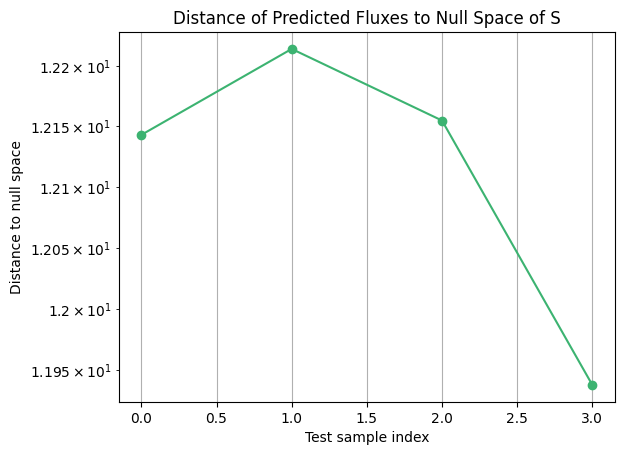

In [59]:
plt.plot(distance_list, marker='o', linestyle='-', color='mediumseagreen')
plt.yscale('log')
plt.xlabel("Test sample index")
plt.ylabel("Distance to null space")
plt.title("Distance of Predicted Fluxes to Null Space of S")
plt.grid(True)
plt.show()

[[np.float32(12.15022), np.float32(12.228601), np.float32(12.126369)],
 [np.float32(12.032584), np.float32(12.111764), np.float32(12.105096)],
 [np.float32(12.2191725), np.float32(11.930223), np.float32(12.057948)],
 [np.float32(12.200582),
  np.float32(12.154171),
  np.float32(12.089519),
  np.float32(11.99022)],
 [np.float32(12.142785),
  np.float32(12.21395),
  np.float32(12.154608),
  np.float32(11.938006)],
 [np.float32(12.027525),
  np.float32(12.053698),
  np.float32(11.990932),
  np.float32(12.068461)],
 [np.float32(12.0830345),
  np.float32(12.222597),
  np.float32(12.277243),
  np.float32(11.999572)],
 [np.float32(11.9693365), np.float32(11.993851), np.float32(11.836056)],
 [np.float32(12.10513),
  np.float32(12.018289),
  np.float32(11.87138),
  np.float32(11.895383)],
 [np.float32(12.143886),
  np.float32(11.940995),
  np.float32(11.956778),
  np.float32(12.050049)]]

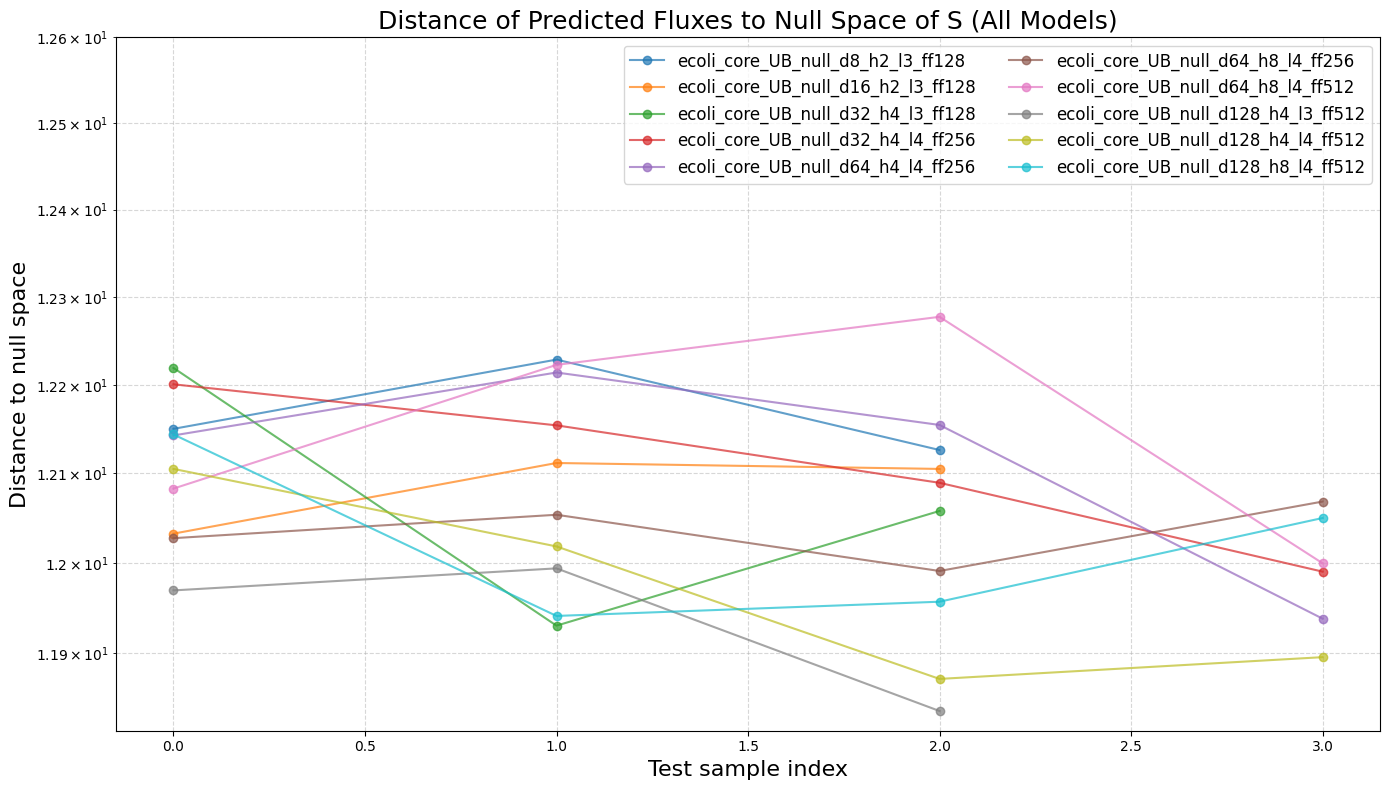

In [75]:
plt.figure(figsize=(14, 8))
for i, distances in enumerate(distance_list_all):
    plt.plot(distances, label=model_names[i], marker='o', linestyle='-', alpha=0.7)

plt.yscale('log')
plt.xlabel("Test sample index", fontsize=16)
plt.ylabel("Distance to null space", fontsize=16)
plt.title("Distance of Predicted Fluxes to Null Space of S (All Models)", fontsize=18)
plt.ylim(top=12.6)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='upper right', ncol=2)
plt.tight_layout()

plt.show()